In [2]:
import csv
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.pyplot import *
import pandas as pd
import numpy as np
from scipy import interpolate
from astropy.io import ascii
from matplotlib.font_manager import FontProperties
from matplotlib import font_manager




import scienceplots
plt.style.use(['high-vis'])
rcParams['pdf.fonttype']=42
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '7.5'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '3.5'})
rcParams.update({'xtick.minor.width': '1.0'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '7.5'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '3.5'})
rcParams.update({'ytick.minor.width': '1.0'})
rcParams.update({'xtick.color': 'k'})
rcParams.update({'font.size': 12})
matplotlib.rcParams['pdf.fonttype']=42
plt.rcParams['ps.fonttype'] = 42  # PostScript Type 42




font_prop = font_manager.FontProperties(family = 'Arial', style = 'normal', size = 7)

In [4]:
llist = []
mag =[]
b_over_a=[]

def hubble_inclination(b_over_a):
  return np.sqrt((b_over_a**2 - 0.2**2) / (1 - 0.2**2))

# Read SDSS cartalog 
data = ascii.read("C:\Users\lenovo\Desktop\Bhardwajetal_2024_nature_inclination_angle-main\SDSS_catalog.csv")
for i in range(0, len(data)):
    try:
      if data['petroMag_r'][i] <= 21 and data['expAB_r'][i] > 0.2:
        b_over_a.append(hubble_inclination(data['expAB_r'][i]))
    except:
      print('error')

bins_collected=[]
means = []
stdevs=[[],[]]

bins=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
bins2 = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1066531125.py, line 9)

In [3]:
#Read FRB host sample
df = pd.read_csv('/Users/ijimin/Desktop/FRBInclinationProject-main/my_data.csv')
ellips = df["ellipse"]

cosis = np.cos(np.radians(ellips))
cosis = cosis.sort_values()

#for 10000 times, take a sample of size of our FRB host sample, make a histogram, then add the histogram to bins collected
for i in range(0,len(bins2)):
  bins_collected.append([])
for i in range(0,10000):
  new_bins = np.histogram(random.sample(b_over_a,len(cosis)),bins=bins)

  for i in range(0,10):
    bins_collected[i].append(new_bins[0][i]/len(cosis))

#Get the means and 68% confidence region for each bin
for i in range(0,10):
  means.append(np.mean(bins_collected[i]))
  bins_collected[i].sort()
  stdevs[0].append(abs(means[i]-bins_collected[i][1600]))  
  stdevs[1].append(abs(bins_collected[i][8400]-means[i]))

b_over_a.append(1)


Text(0, 0.5, 'proportion')

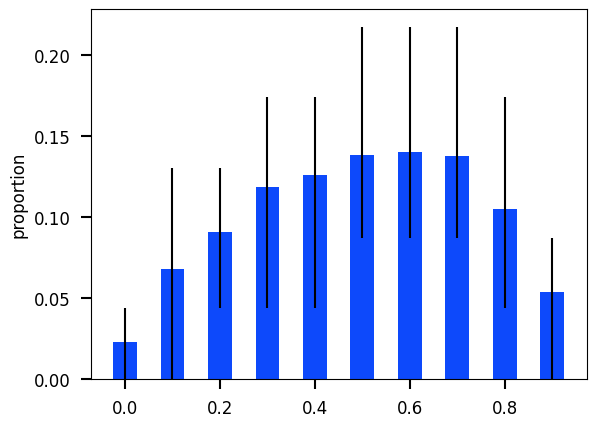

In [4]:
#Plot our bar chart of bin means and stdevs
plt.bar(bins2,means,yerr=stdevs,width=0.05)
plt.ylabel("proportion")

In [5]:
total_samples = []
means = []
stdevs = []
sigma_down = []
sigma_up = []
sdss_raw = []

b_over_a.sort()

#Get our index divided by len() as shown above
indices_normalized = [0]
for i in range(0,len(b_over_a)):
  indices_normalized.append(i/len(b_over_a))

b_over_a.insert(0,0)
#Interpolate between the points to create an actual function
f1 = interpolate.interp1d(b_over_a,indices_normalized)
f2 = interpolate.interp1d(indices_normalized,b_over_a)

In [6]:
#Create 10000 CDF functions of samples randomly taken from the SDSS sample. Works in the exact same way as described above.
for i in range(0,10000):

  new_sample = random.sample(b_over_a,len(cosis))

  indices_normalized_3 = []

  for i in range(1,len(cosis)+1):
    indices_normalized_3.append(i/len(cosis))

  new_sample.insert(0,0)
  new_sample.append(1)

  indices_normalized_3.append(1)
  indices_normalized_3.insert(0,0)

#The 10000 CDF function are put into a list of total_samples
  new_sample.sort()
  sdss_raw.append(new_sample)
  total_samples.append(interpolate.interp1d(new_sample,indices_normalized_3))

In [7]:
#At 100 locations from (0,1), sample each of the 1000 CDF functions at that location and get their mean and 68% confidence interval
for value in np.linspace(0,1,100):
  index_sample =[]
  for sample in total_samples:

    index_sample.append(sample(value))
  means.append(np.mean(index_sample))
  index_sample.sort()

#This is the 68% confidence interval for an ordered list of size 1000
  sigma_down.append(index_sample[1600])
  sigma_up.append(index_sample[8400])

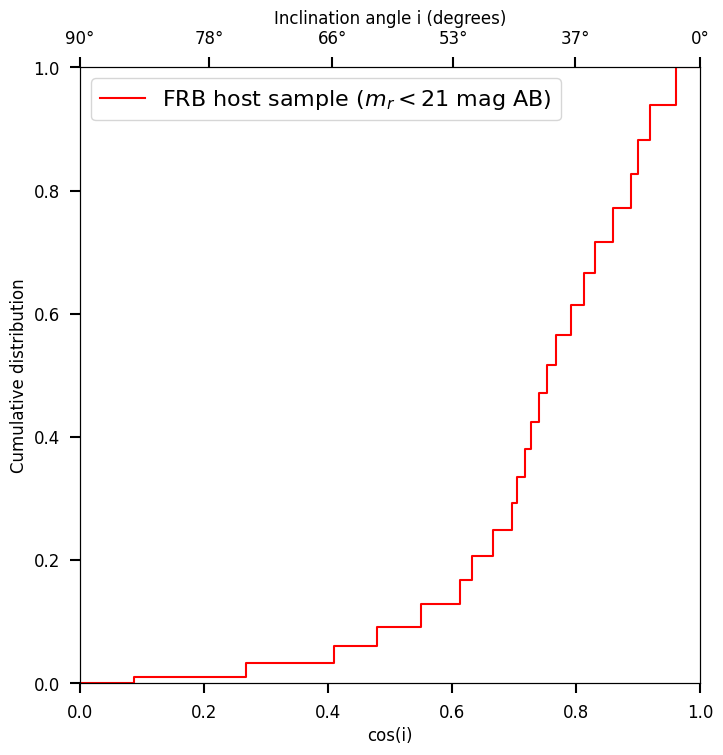

In [8]:
data_i = []
list_cosi = pd.Series(cosis).tolist()
sum = 0
maxsum = 0
for x in list_cosi:
    maxsum += x
for x in list_cosi:
    sum += x
    data_i.append(sum/maxsum)

x = [0] + list_cosi + [1]
y = [0] + data_i + [1]

plt.figure(figsize=(8, 8))
plt.step(x, y, where='mid', color='red')
plt.legend(["FRB host sample ($m_r < 21$ mag AB)"], prop={'size': 16})
plt.ylabel("Cumulative distribution")
plt.xlabel("cos(i)")
# Set x-axis limits to range from 0 to 1
plt.xlim(0, 1)
plt.ylim(0, 1)
ax = plt.gca()
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
angle_degrees = [90, 78, 66, 53, 37, 0]
cos_values = np.cos(np.radians(angle_degrees))
ax2.set_xticks(cos_values)
ax2.set_xticklabels([f'{angle}°' for angle in angle_degrees])
ax2.set_xlabel('Inclination angle i (degrees)')
plt.show()

Text(0, 0.5, 'probability')

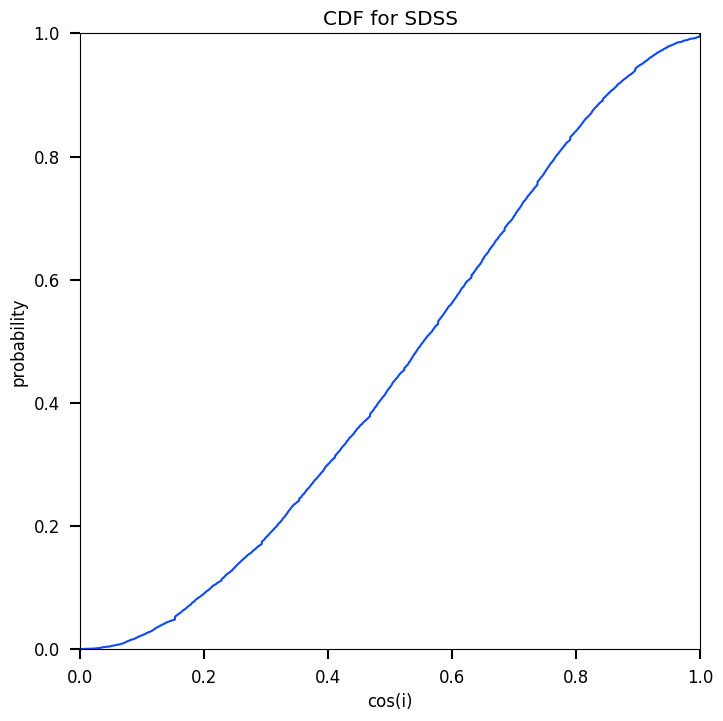

In [9]:
#make a cumulative distribution function for our SDSS sample
from scipy import interpolate

b_over_a.sort()

#Get our index divided by len() as shown above
indices_normalized = [0]

for i in range(0,len(b_over_a)):
  indices_normalized.append(i/len(b_over_a))


b_over_a.insert(0,0)

#Interpolate between the points to create an actual function
f1 = interpolate.interp1d(b_over_a,indices_normalized)

#Plot our function
plt.figure(figsize=(8, 8))
plt.plot(np.linspace(0,1,10000),f1(np.linspace(0,1,10000)))
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("CDF for SDSS")
plt.xlabel("cos(i)")
plt.ylabel("probability")

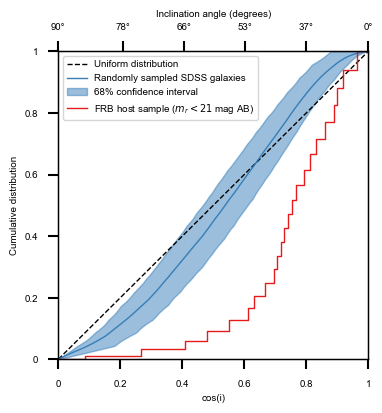

In [10]:
'''
Figure 1 Key:
Uniform distribution: Black dashed line
Randomly sampled SDSS galaxies: Solid blue line (color code: #377eb8)
68% confidence interval: Grey shaded area with 50% opacity
FRB host sample ($m_r < 21$ mag AB): Solid red step line (color code: #e41a1c)

'''

# Figure setup
plt.figure(figsize=(4, 4))

# Plotting the main lines and filled areas
plt.plot([0, 1], [0, 1], color='black', linestyle='dashed', linewidth=1)
plt.plot(np.linspace(0, 1, 100), means, color='#377eb8', linewidth=1)
plt.fill_between(np.linspace(0, 1, 100), sigma_down, sigma_up, color='#377eb8', alpha=0.5)

# Setting axis labels with the specified font
plt.ylabel("Cumulative distribution", fontproperties=font_prop)
plt.xlabel("cos(i)", fontproperties=font_prop)

# Setting axis limits
plt.xlim(left=0, right=1)
plt.ylim(bottom=0, top=1)

# Customizing axis spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1) 

# Plotting the step line
plt.step(x, y, where='mid', color='#e41a1c', linewidth=1, linestyle = '-')

# Adding a legend with the specified font properties
plt.legend(["Uniform distribution","Randomly sampled SDSS galaxies", 
            "68% confidence interval", "FRB host sample ($m_r < 21$ mag AB)"], 
           prop=font_prop)

# Formatting y-axis ticks
ax.set_yticks(np.linspace(0, 1, 6))  # Set y-tick positions
ax.set_yticklabels([f'{tick:g}' for tick in ax.get_yticks()], fontproperties=font_prop)  # Format y-tick labels without trailing zeros

# Formatting x-axis ticks
ax.set_xticks(np.linspace(0, 1, 6))  # Set x-tick positions
ax.set_xticklabels([f'{tick:g}' for tick in ax.get_xticks()], fontproperties=font_prop)  # Format x-tick labels without trailing zeros

# Setting up secondary x-axis for angle degrees
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
angle_degrees = [90, 78, 66, 53, 37, 0]
cos_values = np.cos(np.radians(angle_degrees))
ax2.set_xticks(cos_values)
ax2.set_xticklabels([f'{angle}°' for angle in angle_degrees], fontproperties= font_prop)
ax2.set_xlabel('Inclination angle (degrees)', fontproperties= font_prop)

plt.savefig('host_sdss_frb_revised.pdf', format='pdf', bbox_inches='tight')
plt.show()  # Optional, if you want to display the plot
plt.close()  # Close the plot to release the memory

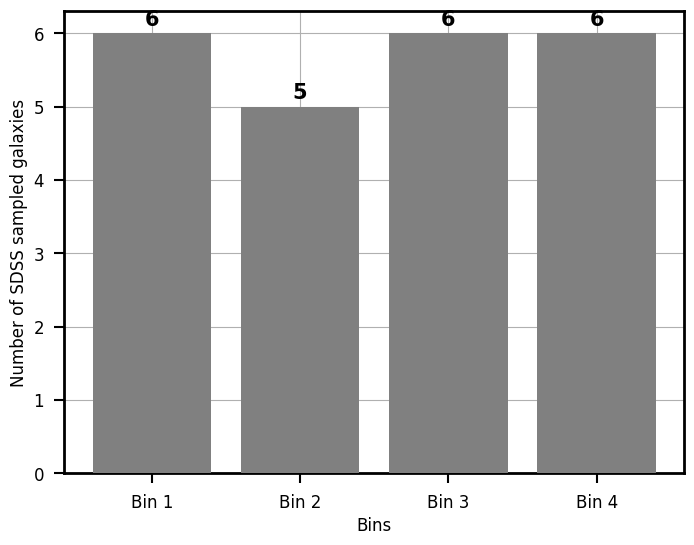

84.97788494114025
74.35201788584517
0.4948182079307959
0.7136300480309383
0.9167717909578201


In [11]:
bins = [0, 0.1680291888743596, 0.4682269573504244, 0.827890108270214]
A=[0.0, 0.02134836458150878, 0.04277992676588367, 0.06283638894705285, 0.09621998234904802, 0.15924299019487495, 0.19606425218589685, 0.24265691323543984, 0.2990515163694877, 0.34852324814991636, 0.422247661907678, 0.4822261444598649, 0.5394627966004603, 0.599445887886108, 0.6567744447883276, 0.7159990314993804, 0.7756788988603098, 0.8323545994597761, 0.8891664833886921, 0.928602637058875, 0.9599912142876569, 0.9798625378411295, 1.0]

ang = [[],[],[],[]]
for x in A:
    if x < bins[1]: 
        ang[0].append((x))
    elif x >= bins[1] and x < bins[2]: 
        ang[1].append((x))
    elif x >= bins[2] and x < bins[3]: 
        ang[2].append((x))
    else: 
        ang[3].append((x))

num = [len(ang[0]), len(ang[1]), len(ang[2]), len(ang[3])]
labels = ['Bin 1', 'Bin 2', 'Bin 3', 'Bin 4']
plt.figure(figsize=(8, 6))
bar_chart = plt.bar(labels, num, zorder=5, color = 'gray')
for bar in bar_chart:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, yval, ha='center', va='bottom', fontsize = 15, fontweight = 'bold')

plt.xlabel('Bins')
plt.ylabel('Number of SDSS sampled galaxies')
plt.grid(True)
# Set axes thickness
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)  

plt.show()
print(np.rad2deg(np.arccos(np.percentile(A,17))))
print(np.rad2deg(np.arccos(np.percentile(A,34))))
print(np.percentile(A,51))
print(np.percentile(A,68))
print(np.percentile(A,85))

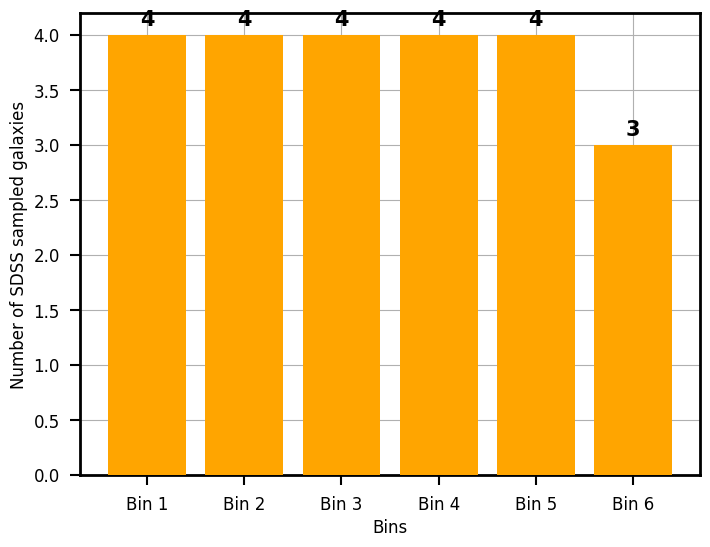

In [12]:
bins = [0,
0.09579597441006797,
0.25987732875335423,
0.5060196679031522,
0.7510362992901748,
0.9357523542859412,
1]
ang = [[],[],[],[],[],[]]
for x in A:
    if x < bins[1]: 
        ang[0].append((x))
    elif x >= bins[1] and x < bins[2]: 
        ang[1].append((x))
    elif x >= bins[2] and x < bins[3]: 
        ang[2].append((x))
    elif x >= bins[3] and x < bins[4]:
        ang[3].append((x))
    elif x >= bins[4] and x < bins[5]:
        ang[4].append((x))
    else: 
        ang[5].append((x))

num = [len(ang[0]), len(ang[1]), len(ang[2]), len(ang[3]), len(ang[4]), len(ang[5])]
labels = ['Bin 1', 'Bin 2', 'Bin 3', 'Bin 4', 'Bin 5', 'Bin 6']
plt.figure(figsize=(8, 6))
bar_chart = plt.bar(labels, num, zorder=5, color = 'orange')
for bar in bar_chart:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, yval, ha='center', va='bottom', fontsize = 15, fontweight = 'bold')


plt.xlabel('Bins')
plt.ylabel('Number of SDSS sampled galaxies')
plt.grid(True)
# Set axes thickness
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)  

plt.show()

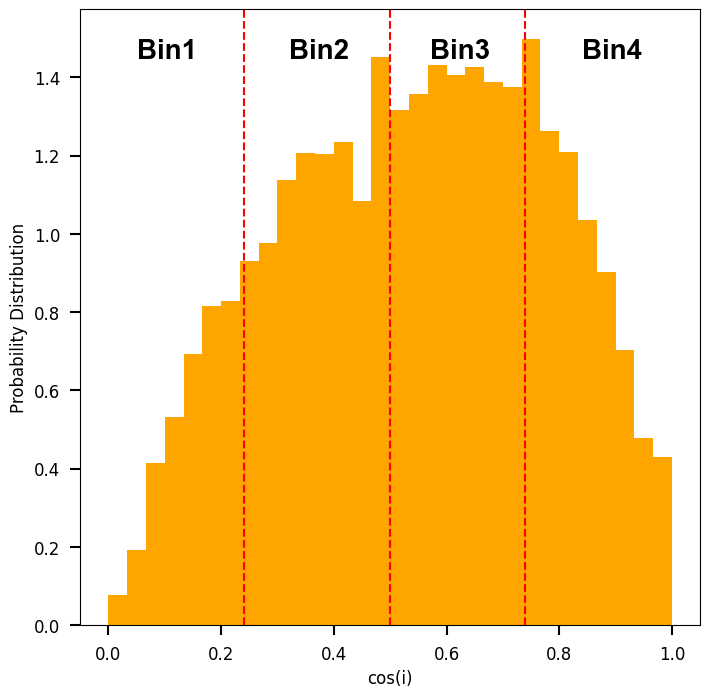

In [13]:
fig, ax1 = plt.subplots(figsize=(8,8))
n, bins, patches = ax1.hist(b_over_a, bins=30, color = 'orange',density=True)
ax1.set_xlabel('cos(i)')
ax1.set_ylabel('Probability Distribution')
ax1.axvline(x=0.74, color='red', linestyle='--')
ax1.axvline(x=0.5, color='red', linestyle='--')
ax1.axvline(x=0.24, color='red', linestyle='--')
ax1.text(0.05, max(n), 'Bin1', color='black', verticalalignment='top',fontsize=20, font = 'Arial', fontweight = 'bold')
ax1.text(0.32, max(n), 'Bin2', color='black', verticalalignment='top',fontsize=20, font = 'Arial', fontweight = 'bold')
ax1.text(0.57, max(n), 'Bin3', color='black', verticalalignment='top',fontsize=20, font = 'Arial', fontweight = 'bold')
ax1.text(0.84, max(n), 'Bin4', color='black', verticalalignment='top',fontsize=20, font = 'Arial', fontweight = 'bold')

plt.savefig("sdss_dist_hist.pdf",bbox_inches="tight",dpi=200)

In [14]:
def cdf_plot(data,ci):
    total_samples = []
    means = []
    stdevs = []
    sigma_down = []
    sigma_up = []
    new_sample = []
    
    for i in range(0,10000):
        new_sample = random.sample(data,len(cosis))
        indices_normalized_3 = []
        for i in range(1,len(cosis)+1):
            indices_normalized_3.append(i/len(cosis))
        #print(len(new_sample))
        new_sample.insert(0,0)
        new_sample.append(1)
        indices_normalized_3.append(1)
        indices_normalized_3.insert(0,0)
        new_sample.sort()
        # print(len(new_sample),len(indices_normalized_3))
        total_samples.append(interpolate.interp1d(new_sample,indices_normalized_3))

    for value in np.linspace(0,1,100):
        index_sample = []
        for sample in total_samples:
            index_sample.append(sample(value))
        means.append(np.mean(index_sample))
        index_sample.sort()

        #68% confidence interval
        sigma_down.append(index_sample[160])
        sigma_up.append(index_sample[840])
        #print(means)
    plt.plot(np.linspace(0,1,100),means)
    if ci:
        plt.fill_between(np.linspace(0,1,100),sigma_down, sigma_up,alpha = 0.5)

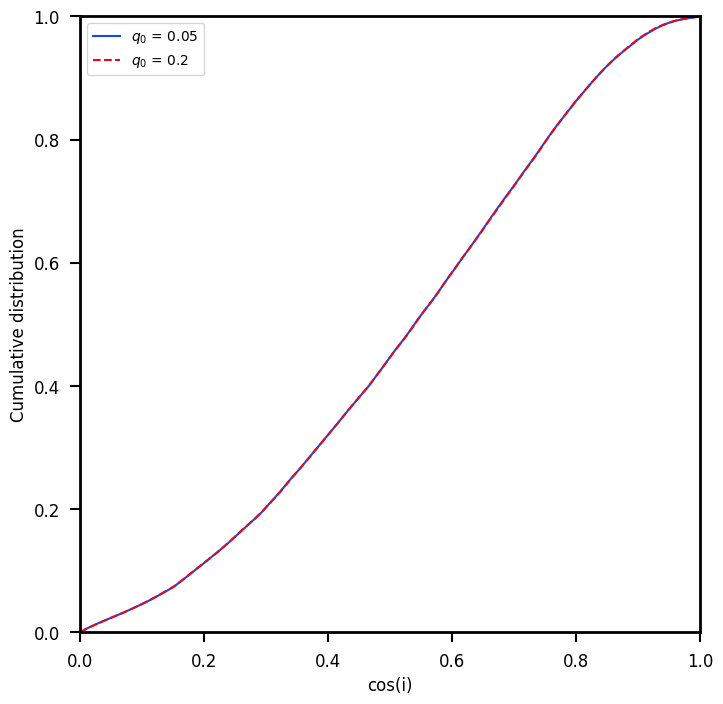

In [15]:
plt.figure(figsize = (8,8))
cdf_plot(b_over_a,False)
cdf_plot(b_over_a,False)
plt.legend(["$q_0$ = 0.05", "$q_0$ = 0.2"], prop={'size': 10})
plt.ylabel("Cumulative distribution")
plt.xlabel("cos(i)")
plt.xlim(left=0,right = 1)
plt.ylim(bottom = 0, top = 1)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2) 

/var/folders/z3/h1m0y2_x0vvbtm53cs6nww3r0000gn/T/ipykernel_98450/336295110.py:46: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([f'{int(tick) if float(tick).is_integer() else tick:g}' for tick in ax.get_xticks()], fontproperties=font_prop)
/var/folders/z3/h1m0y2_x0vvbtm53cs6nww3r0000gn/T/ipykernel_98450/336295110.py:47: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f'{int(tick) if float(tick).is_integer() else tick:g}' for tick in ax.get_yticks()], fontproperties=font_prop)


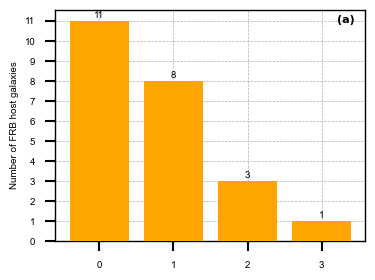

In [16]:
incl_ang = np.array([62.89, 41.10, 21.47, 6.72, 33.22, 38.52, 45.45, 26.84, 44.85, 68.76, 51.26, 80.04, 60, 46.30, 43.17, 43.51, 34.47, 50.23, 36.81, 53.23, 24.99, 41.27, 27.90])

SFR = np.array([4.93,0.03,35.83,15.91,0.73,4.25,0.72,4.10,0.15,\
          0.09,1.89,1.16,0.23,1.62,2.5,2.71,0.62,0.40,7.03,18.28,0.21,0.63,3.51])
sm = np.array([1.33e10,10**(9.47),10**(9.48),10**(9.76),10**(10.28),10**9.97,10**(9.48),\
              10**(9.81),10**(10.99),10**(8.64),10**(10.22),10**(9.91),10**(10.79),10**(9.95),10**(10),\
              10**(10.04),10**(10.39),10**(9.69),10**(10.56),10**(10.73),10**(10.16),10**(10.97),10**(10.37)])
sSFR = np.log10(SFR/sm)


bin1 = []
bin2 = []
bin3 = []
bin4 = []

bins = [[], [], [], []]
a,b,c,d,e = (([90, 76, 60, 42, 0]))
bin_ = [[e,d], [d,c], [c,b], [b,a]]
for angle in incl_ang:
    for idx, (lower_bound, upper_bound) in enumerate(bin_):
        if lower_bound <= angle < upper_bound:
            bins[idx].append(angle)

# Counting the number of angles in each bin
bin_counts = [len(b) for b in bins]
bin_labels = ['Bin 1', 'Bin 2', 'Bin 3', 'Bin 4']

# Plotting
plt.figure(figsize=(4, 3))
ax = plt.gca()
bar_chart = ax.bar(bin_labels, bin_counts, zorder=3, color='orange')
plt.text(3.2, 10.9, "(a)", fontsize = 8, weight='bold')

# Set the maximum number of y-ticks to 16
ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=16))

# Adding labels on top of the bars
for bar in bar_chart:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, '%d' % yval, ha='center', va='bottom', fontsize=7, fontproperties=font_prop)

# Setting labels and grid
plt.ylabel('Number of FRB host galaxies', fontproperties=font_prop)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=0)

ax.set_xticklabels([f'{int(tick) if float(tick).is_integer() else tick:g}' for tick in ax.get_xticks()], fontproperties=font_prop)
ax.set_yticklabels([f'{int(tick) if float(tick).is_integer() else tick:g}' for tick in ax.get_yticks()], fontproperties=font_prop)
ax2.set_xlabel('Inclination angle (degrees)', fontproperties=font_prop, fontsize=7)

# Enhancing the spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(1)
plt.savefig("hist_number_of_host.pdf",bbox_inches="tight",dpi=300)
plt.show()

In [17]:
DMh=np.array([309, 468, 171, 395, 127,22,538,170,190,83,335,149,154,445,34,126,80,94,238,340,16,66,148])

z = np.array([0.3688,0.1415, 0.0469, 0.3437, 0.0707, 0.4780, 0.1139, 0.1582, 0.2847, 0.0087, 0.2365, 0.0430,\
              0.0894, 0.2414, 0.077, 0.2481, 0.3212, 0.2909, 0.1178, 0.2342, 0.0112, 0.1293, 0.2796])

In [18]:
def values_for_bins(data):
    bins_data = [[], [], [], []]
    for i, value in enumerate(data):
        for idx, (min_val, max_val) in enumerate(bin_):
            if min_val <= incl_ang[i] < max_val:
                bins_data[idx].append(value)
    return bins_data

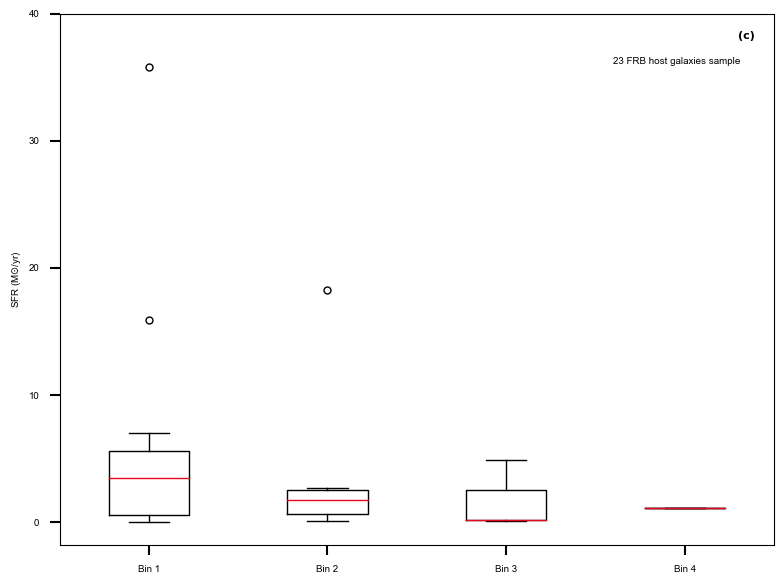

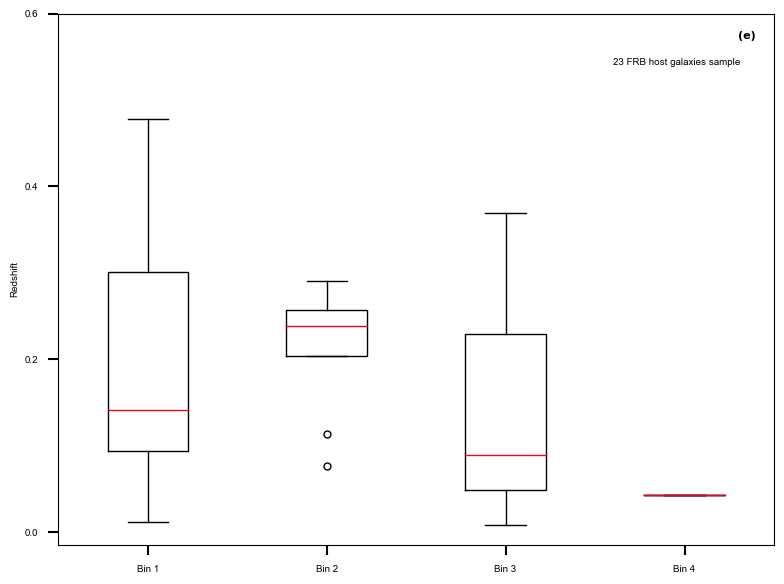

Font 'default' does not have a glyph for '\u207b' [U+207b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u207b' [U+207b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u207b' [U+207b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u207b' [U+207b], substituting with a dummy symbol.


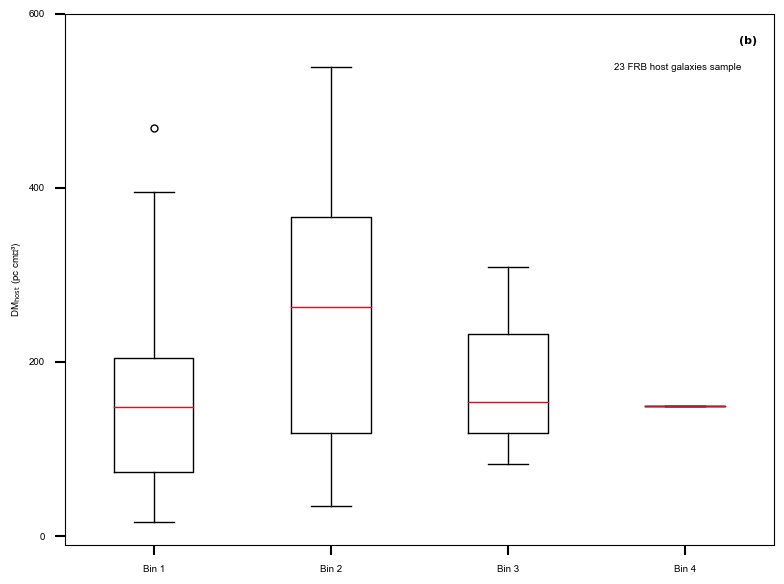

In [19]:
sfr_bins = values_for_bins(SFR)
sffr_bins = values_for_bins(sSFR)
z_bins = values_for_bins(z)
dmh_bins = values_for_bins(DMh)

def plot_and_save(data, title, filename):
    plt.figure(figsize=(8, 6))
    plt.boxplot(data, boxprops=dict(linewidth=1), whiskerprops=dict(linewidth=1),
                capprops=dict(linewidth=1), medianprops=dict(linewidth=1), flierprops=dict(marker='o', markersize=5, linestyle='none', linewidth=1))
    plt.xticks(ticks=[1, 2, 3, 4], labels=['Bin 1', 'Bin 2', 'Bin 3', 'Bin 4'], fontproperties=font_prop)

    if data == sfr_bins: 
        plt.ylabel('SFR (M$\odot$/yr)', fontproperties=font_prop)
        plt.text(3.6, 36, "23 FRB host galaxies sample", fontsize=7, fontproperties=font_prop)
        plt.text(4.3, 38, "(c)", fontsize=8, weight='bold')
        plt.yticks(ticks=[0, 10, 20, 30, 40], fontproperties=font_prop)

    elif data == sffr_bins: 
        plt.ylabel('sSFR (M$\odot$/yr)', fontproperties=font_prop)
        plt.yticks(ticks=[-12, -11, -10, -9], fontproperties=font_prop)
        
    elif data == z_bins : 
        plt.ylabel('Redshift', fontproperties=font_prop)
        plt.text(4.3, 0.57, "(e)", fontsize=8, weight='bold')
        plt.text(3.6, 0.54, "23 FRB host galaxies sample", fontsize=7, fontproperties=font_prop)
        plt.yticks(ticks=[0, 0.2, 0.4, 0.6], fontproperties=font_prop)

    elif data == dmh_bins: 
        plt.ylabel('DM$_{\mathrm{host}}$ (pc cm⁻³)', fontproperties=font_prop)
        plt.text(4.3, 565, "(b)", fontsize=8, weight='bold')
        plt.text(3.6, 535, "23 FRB host galaxies sample", fontsize=7, fontproperties=font_prop)
        plt.yticks(ticks=[0, 200, 400, 600], fontproperties=font_prop)

    plt.tight_layout()
    plt.savefig(filename, format='pdf', bbox_inches="tight")
    plt.show()


plot_and_save(sfr_bins, 'Boxplot of SFR', 'SFRBoxplot.pdf')
#plot_and_save(sffr_bins, 'Boxplot of SFFR', 'sSFR_boxplot.pdf')
plot_and_save(z_bins, 'Boxplot of z', 'z_Boxplot.pdf')
plot_and_save(dmh_bins, 'Boxplot of DMh', 'DMhBoxplot_.pdf')

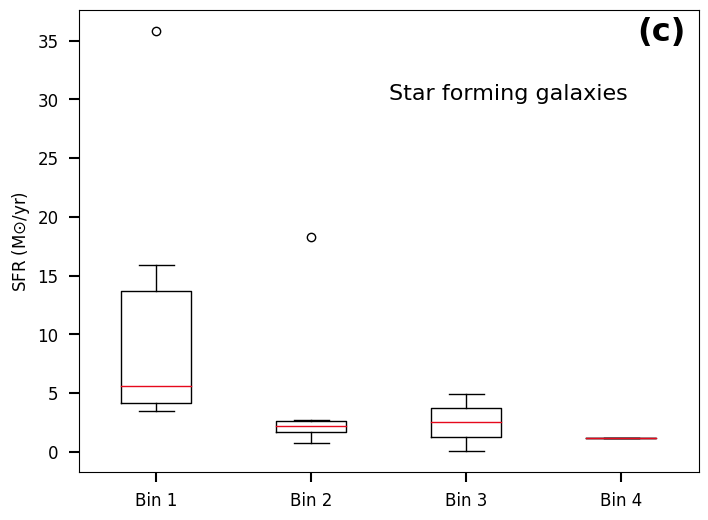

In [20]:
index_sf = np.where(sSFR > -10)[0]
SFR_sf = SFR[index_sf]
i_sf = incl_ang[index_sf]

bins = [[e, d], [d, c], [c, b], [b, a]]
bin_labels = ['Bin 1', 'Bin 2', 'Bin 3', 'Bin 4']
bins_data = {label: [] for label in bin_labels}

for angle, sfr_value in zip(i_sf, SFR_sf):
    for idx, (min_val, max_val) in enumerate(bins):
        if min_val <= angle < max_val:
            bins_data[bin_labels[idx]].append(sfr_value)

plt.figure(figsize=(8,6))
plt.boxplot([bins_data[label] for label in bin_labels], labels=bin_labels)
plt.ylabel('SFR (M$\odot$/yr)')
plt.text(2.5, 30, "Star forming galaxies", fontsize = 16)
plt.text(4.1, 35, "(c)", fontsize = 23, weight='bold')

plt.savefig('SF_SFR_Boxplot_.pdf', bbox_inches="tight",dpi=200)
plt.show()

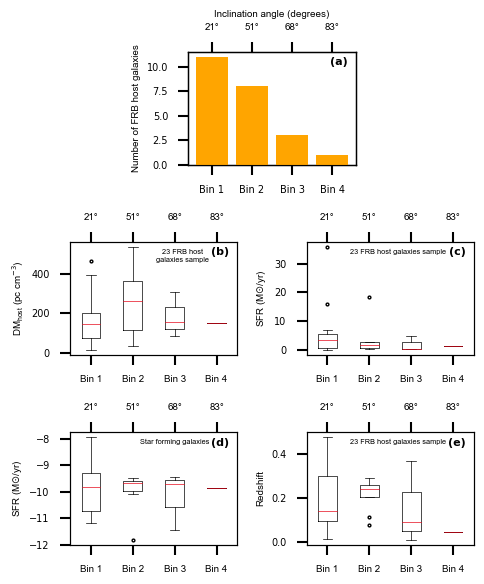

In [25]:
# Creating the figure and grid layout using subplot2grid
plt.figure(figsize=(5, 6))

# (a) Plot at the top center
ax_a = plt.subplot2grid((3, 4), (0, 1), colspan=2)
bin_labels = ['Bin 1', 'Bin 2', 'Bin 3', 'Bin 4']
bin_counts = [len(bin_) for bin_ in [values_for_bins(incl_ang)[i] for i in range(4)]]
bar_chart = ax_a.bar(bin_labels, bin_counts, zorder=3, color='orange')
ax_a.set_ylabel('Number of FRB host galaxies', fontproperties=font_prop)
#ax_a.text(3.15, max(bin_counts) * 0.9, "(a)", fontsize=8, weight='bold')
# Add text to the upper right corner of each subplot
ax_a.text(0.95, 0.95, "(a)", fontsize=8, weight='bold', horizontalalignment='right',\
          verticalalignment='top', transform=ax_a.transAxes)
ax_a.tick_params(axis='both', which='major', labelsize=7)
for spine in ax_a.spines.values():
    spine.set_linewidth(1)

ax2_a = ax_a.twiny()
ax2_a.set_xlim(ax_a.get_xlim())
mean_bin = [21, 51, 68, 83]  # Mean bin angles
ax2_a.set_xticks([i for i in range(len(mean_bin))])  # Align the x-ticks with the bars directly
ax2_a.set_xticklabels([f'{angle}°' for angle in mean_bin], fontproperties=font_prop)
ax2_a.set_xlabel('Inclination angle (degrees)', fontproperties=font_prop, fontsize=7)
ax2_a.tick_params(axis='x', labelsize=7)

# (b) DMh plot in the second row
ax_b = plt.subplot2grid((3, 4), (1, 0), colspan=2)
ax_b.boxplot(dmh_bins, boxprops=dict(linewidth=0.5), whiskerprops=dict(linewidth=0.5),
             capprops=dict(linewidth=0.5), medianprops=dict(linewidth=0.5), flierprops=dict(marker='o', markersize=2, linestyle='none', linewidth=0.25))
ax_b.set_xticks(ticks=[1, 2, 3, 4])
ax_b.set_xticklabels(bin_labels, fontproperties=font_prop)
ax_b.set_ylabel(r'DM$_{\mathdefault{host}}$ (pc cm$^{-3}$)', fontproperties=font_prop)
ax_b.text(0.95, 0.95, "(b)", fontsize=8, weight='bold', horizontalalignment='right',\
          verticalalignment='top', transform=ax_b.transAxes)
ax_b.text(0.83, 0.94, "23 FRB host   ", fontsize=5.3, fontproperties=font_prop,\
          horizontalalignment='right', verticalalignment='top', transform=ax_b.transAxes)
ax_b.text(0.83, 0.87, "galaxies sample", fontsize=5.3, fontproperties=font_prop,\
          horizontalalignment='right', verticalalignment='top', transform=ax_b.transAxes)
#ax_b.text(2.3, 455, "23 FRB host galaxies sample", fontsize=7, fontproperties=font_prop)
ax_b.tick_params(axis='y', labelsize=7)
ax_b.tick_params(axis='x', labelsize=7)

ax2_b = ax_b.twiny()
ax2_b.set_xlim(ax_b.get_xlim())
ax2_b.set_xticks([1, 2, 3, 4])
ax2_b.set_xticklabels(['21°', '51°', '68°', '83°'], fontproperties=font_prop)
ax2_b.tick_params(axis='x', labelsize=7)

# (c) SFR plot in the second row
ax_c = plt.subplot2grid((3, 4), (1, 2), colspan=2)
ax_c.boxplot(sfr_bins, boxprops=dict(linewidth=0.5), whiskerprops=dict(linewidth=0.5),
             capprops=dict(linewidth=0.5), medianprops=dict(linewidth=0.5), flierprops=dict(marker='o', markersize=2, linestyle='none', linewidth=0.25))
ax_c.set_xticks(ticks=[1, 2, 3, 4])
ax_c.set_xticklabels(bin_labels, fontproperties=font_prop)
ax_c.set_ylabel('SFR (M$\odot$/yr)', fontproperties=font_prop)
ax_c.text(0.95, 0.95, "(c)", fontsize=8, weight='bold', horizontalalignment='right',\
          verticalalignment='top', transform=ax_c.transAxes)
ax_c.text(0.83, 0.94, "23 FRB host galaxies sample", fontsize=5.3, fontproperties=font_prop,\
          horizontalalignment='right', verticalalignment='top', transform=ax_c.transAxes)
#ax_c.text(2.3, 31, "23 FRB host galaxies sample", fontsize=7, fontproperties=font_prop)
ax_c.tick_params(axis='y', labelsize=7)
ax_c.tick_params(axis='x', labelsize=7)

ax2_c = ax_c.twiny()
ax2_c.set_xlim(ax_c.get_xlim())
ax2_c.set_xticks([1, 2, 3, 4])
ax2_c.set_xticklabels(['21°', '51°', '68°', '83°'], fontproperties=font_prop)
ax2_c.tick_params(axis='x', labelsize=7)

# (d) sSFR plot in the third row, left
ax_d = plt.subplot2grid((3, 4), (2, 0), colspan=2)
ax_d.boxplot(sffr_bins, boxprops=dict(linewidth=0.5), whiskerprops=dict(linewidth=0.5),
             capprops=dict(linewidth=0.5), medianprops=dict(linewidth=0.5), flierprops=dict(marker='o', markersize=2, linestyle='none', linewidth=0.25))
ax_d.set_xticks(ticks=[1, 2, 3, 4])
ax_d.set_xticklabels(bin_labels, fontproperties=font_prop)
ax_d.set_ylabel('SFR (M$\odot$/yr)', fontproperties=font_prop)
ax_d.text(0.95, 0.95, "(d)", fontsize=8, weight='bold', horizontalalignment='right',\
          verticalalignment='top', transform=ax_d.transAxes)
ax_d.text(0.83, 0.94, "Star forming galaxies", fontsize=5.3, fontproperties=font_prop,\
          horizontalalignment='right', verticalalignment='top', transform=ax_d.transAxes)
#ax_d.text(2.3, 0.95, "Star forming galaxies", fontsize=7, fontproperties=font_prop, horizontalalignment='right',\
#          verticalalignment='top', transform=ax_d.transAxes)
#ax_d.text(2.3,0.42, "Star forming galaxies", fontsize=7, fontproperties=font_prop)
ax_d.tick_params(axis='y', labelsize=7)
ax_d.tick_params(axis='x', labelsize=7)

ax2_d = ax_d.twiny()
ax2_d.set_xlim(ax_d.get_xlim())
ax2_d.set_xticks([1, 2, 3, 4])
ax2_d.set_xticklabels(['21°', '51°', '68°', '83°'], fontproperties=font_prop)
ax2_d.tick_params(axis='x', labelsize=7)

# (e) Redshift plot in the third row, right
ax_e = plt.subplot2grid((3, 4), (2, 2), colspan=2)
ax_e.boxplot(z_bins, boxprops=dict(linewidth=0.5), whiskerprops=dict(linewidth=0.5),
             capprops=dict(linewidth=0.5), medianprops=dict(linewidth=0.5), flierprops=dict(marker='o', markersize=2, linestyle='none', linewidth=0.25))
ax_e.set_xticks(ticks=[1, 2, 3, 4])
ax_e.set_xticklabels(bin_labels, fontproperties=font_prop)
ax_e.set_ylabel('Redshift', fontproperties=font_prop)
ax_e.text(0.95, 0.95, "(e)", fontsize=8, weight='bold', horizontalalignment='right',\
          verticalalignment='top', transform=ax_e.transAxes)
ax_e.text(0.83, 0.94, "23 FRB host galaxies sample", fontsize=5.3, fontproperties=font_prop,\
          horizontalalignment='right', verticalalignment='top', transform=ax_e.transAxes)
#ax_e.text(2.3, 0.42, "23 FRB host galaxies sample", fontsize=7, fontproperties=font_prop)
ax_e.tick_params(axis='y', labelsize=7)
ax_e.tick_params(axis='x', labelsize=7)

ax2_e = ax_e.twiny()
ax2_e.set_xlim(ax_e.get_xlim())
ax2_e.set_xticks([1, 2, 3, 4])
ax2_e.set_xticklabels(['21°', '51°', '68°', '83°'], fontproperties=font_prop)
ax2_e.tick_params(axis='x', labelsize=7)
# Adjust layout: Set padding between the plots
plt.subplots_adjust(wspace=0.5,hspace=0.3)

plt.tight_layout()
plt.savefig("Figure_2.pdf", format='pdf', bbox_inches="tight", dpi=300)
plt.show()